In [35]:
import pandas as pd
import numpy as np                        
import matplotlib.pyplot as plt           

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

In [36]:
AAPL_df = pd.read_csv("AAPL_historical_data.csv")

AAPL_df.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-10-01,139.136673,142.649994,142.919998,139.110001,141.899994,94639600
1,2021-10-04,135.713120,139.139999,142.210007,138.270004,141.759995,98322000
2,2021-10-05,137.634628,141.110001,142.240005,139.360001,139.490005,80861100
3,2021-10-06,138.502716,142.000000,142.149994,138.369995,139.470001,83221100
4,2021-10-07,139.760910,143.289993,144.220001,142.720001,143.059998,61732700
5,2021-10-08,139.380539,142.899994,144.179993,142.559998,144.029999,58773200
6,2021-10-11,139.292725,142.809998,144.809998,141.809998,142.270004,64452200
7,2021-10-12,138.024780,141.509995,143.250000,141.039993,143.229996,73035900
8,2021-10-13,137.439545,140.910004,141.399994,139.199997,141.240005,78762700
9,2021-10-14,140.219345,143.759995,143.880005,141.509995,142.110001,69907100


In [37]:
AAPL_df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,202.613590,204.591228,206.634761,202.336962,204.354880,6.357783e+07
std,51.261960,50.366183,50.775127,49.893761,50.294542,2.855109e+07
min,122.827606,125.019997,127.769997,124.169998,126.010002,1.791060e+07
25%,162.922287,166.140003,167.872498,164.590000,166.092499,4.489712e+07
50%,189.051575,191.264999,192.620003,189.700005,190.959999,5.517040e+07
75%,234.510593,236.359997,238.145000,233.420002,235.509995,7.514605e+07
max,341.070007,341.070007,345.339996,338.750000,341.079987,3.186799e+08


In [38]:
AAPL_df.shape

(1254, 7)

followed the 5(a) loading method

In [39]:
AAPL_df = pd.read_csv("AAPL_historical_data.csv", parse_dates = ['Date'], index_col = 'Date')

In [40]:
AAPL_df.head(10)

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-10-01,139.136673,142.649994,142.919998,139.110001,141.899994,94639600
2021-10-04,135.713120,139.139999,142.210007,138.270004,141.759995,98322000
2021-10-05,137.634628,141.110001,142.240005,139.360001,139.490005,80861100
2021-10-06,138.502716,142.000000,142.149994,138.369995,139.470001,83221100
2021-10-07,139.760910,143.289993,144.220001,142.720001,143.059998,61732700
2021-10-08,139.380539,142.899994,144.179993,142.559998,144.029999,58773200
2021-10-11,139.292725,142.809998,144.809998,141.809998,142.270004,64452200
2021-10-12,138.024780,141.509995,143.250000,141.039993,143.229996,73035900
2021-10-13,137.439545,140.910004,141.399994,139.199997,141.240005,78762700


In [41]:
# Drop null values from the dataframe
AAPL_df = AAPL_df.dropna()

# Display the sumof null values
AAPL_df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [42]:
AAPL_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-10-01 to 2026-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1254 non-null   float64
 1   Close      1254 non-null   float64
 2   High       1254 non-null   float64
 3   Low        1254 non-null   float64
 4   Open       1254 non-null   float64
 5   Volume     1254 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.6 KB


Adapted from Tutorial 6(a)

In [43]:
# plotds is method to plot time series, ACF and PACF
def plotds(xt, nlag = 30, fig_size = (12, 10)):            # Function to plot time series, ACF, and PACF
    if not isinstance(xt, pd.Series):                      # Check if input is not a pandas Series
         xt = pd.Series(xt)                                # Convert input to pandas Series if needed
         
    plt.figure(figsize = fig_size)                         # Create a figure with specified size
    layout = (2, 2)                                        # Define grid layout (2 rows x 2 columns)
    
    ax_xt = plt.subplot2grid(layout, (0, 0), colspan = 2)  # Top plot spans both columns (time series)
    ax_acf= plt.subplot2grid(layout, (1, 0))               # Bottom-left plot for ACF
    ax_pacf = plt.subplot2grid(layout, (1, 1))             # Bottom-right plot for PACF
    
    xt.plot(ax = ax_xt)                                    # Plot the time series data
    ax_xt.set_title('Time Series')                         # Set title for time series plot
    
    plot_acf(xt, lags = nlag, ax = ax_acf)                   # Plot autocorrelation function (ACF)
    plot_pacf(xt, lags = nlag, ax = ax_pacf)                 # Plot partial autocorrelation function (PACF)
    
    plt.tight_layout()                                     # Adjust layout to prevent overlapping
    return None                                            # Function returns nothing

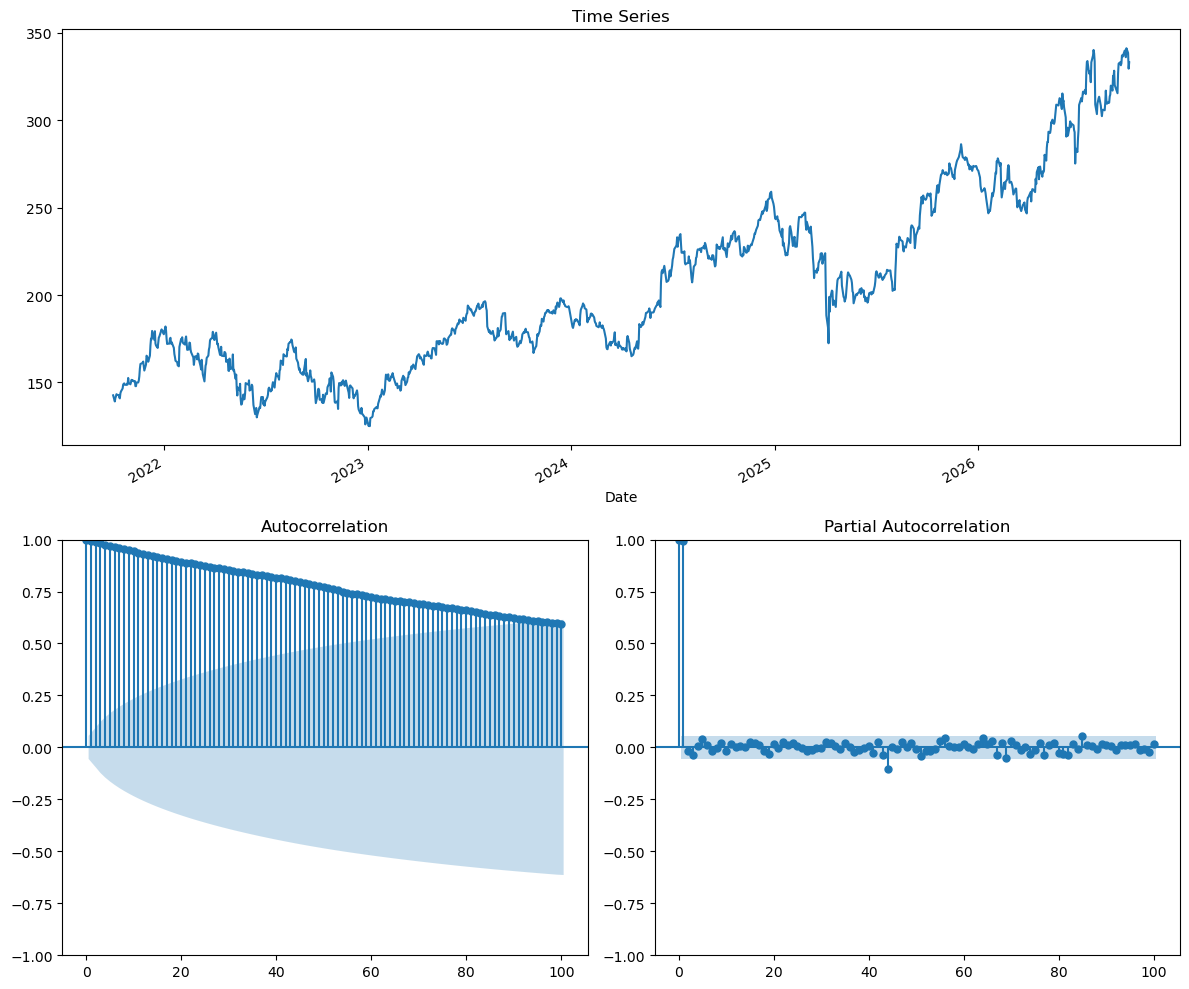

In [44]:
# Display plot of close column and Date index
plotds(AAPL_df['Close'], nlag = 100)

In [45]:
# Row position of the middle of the dataset, used to divide the series into two equal halves
mid = len(AAPL_df) // 2

# Calculate the mean value of first half and second half
mean1, mean2 = AAPL_df.iloc[:mid].Close.mean(), AAPL_df.iloc[mid:].Close.mean()

# Calculate the variance value of  first half and second half
var1, var2 = AAPL_df.iloc[:mid].Close.var(), AAPL_df.iloc[mid:].Close.var()

# Display mean and variance of two parts of the time series
print('mean1 = %f, mean2 = %f' % (mean1, mean2))
print('variance1 = %f, variance2 = %f' % (var1, var2))

mean1 = 164.875439, mean2 = 244.307017
variance1 = 306.218870, variance2 = 1611.610899


In [46]:
from statsmodels.tsa.stattools import adfuller

# Call adfuller() function to calculate the values
adf_result = adfuller(AAPL_df.Close.tolist())
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])

ADF Statistic: -0.389084
p-value: 0.911905


p = 0.91 > 0.05 so the series is non-stationary so differencing is needed

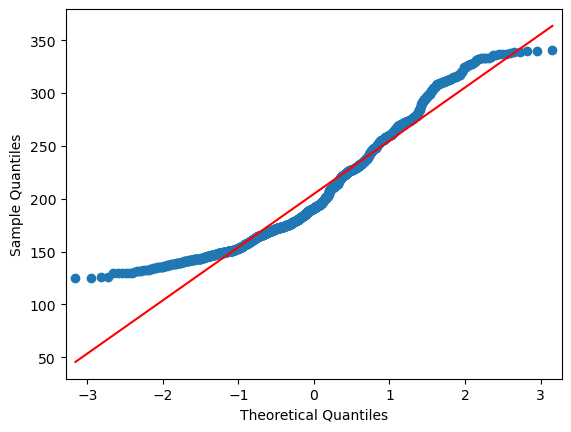

In [47]:
import statsmodels.api as sm

# qqplot for the 'Close' column : help us to understand normal distribution or not
x = sm.qqplot(AAPL_df['Close'], line = 's')

The points are not following the red line at the beginning and at the end, so the Close prices are not normally distributed

In [48]:
# Store one difference value of the 'Close' column
first_order_diff = AAPL_df['Close'].diff(1)

# Display the first five records
first_order_diff.head()

Date
2021-10-01         NaN
2021-10-04   -3.509995
2021-10-05    1.970001
2021-10-06    0.889999
2021-10-07    1.289993
Name: Close, dtype: float64

In [49]:
# Remove the first row because it is empty (NaN)
first_order_diff = AAPL_df['Close'].diff(1).dropna()

# Display the first five records
first_order_diff.head()

Date
2021-10-04   -3.509995
2021-10-05    1.970001
2021-10-06    0.889999
2021-10-07    1.289993
2021-10-08   -0.389999
Name: Close, dtype: float64

Text(0.5, 1.0, 'First-order differences of AAPL during Oct 2021-Sep 2026')

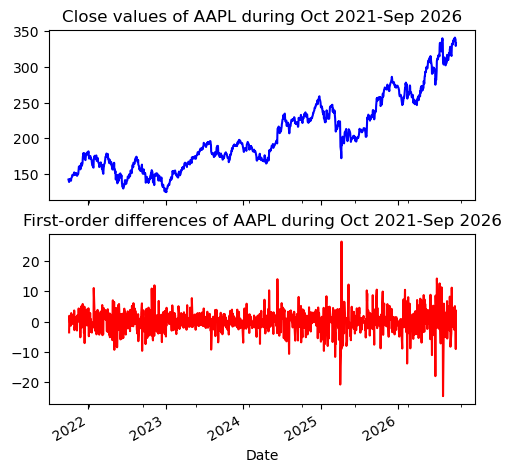

In [50]:
# Declare the fig and ax as two arguments 
fig, ax = plt.subplots(2, sharex = True)
fig.set_size_inches(5.5, 5.5)
AAPL_df['Close'].plot(ax = ax[0], color = 'b')
ax[0].set_title('Close values of AAPL during Oct 2021-Sep 2026')
first_order_diff.plot(ax = ax[1], color = 'r')
ax[1].set_title('First-order differences of AAPL during Oct 2021-Sep 2026')

ADF Statistic: -33.730495
p-value: 0.000000


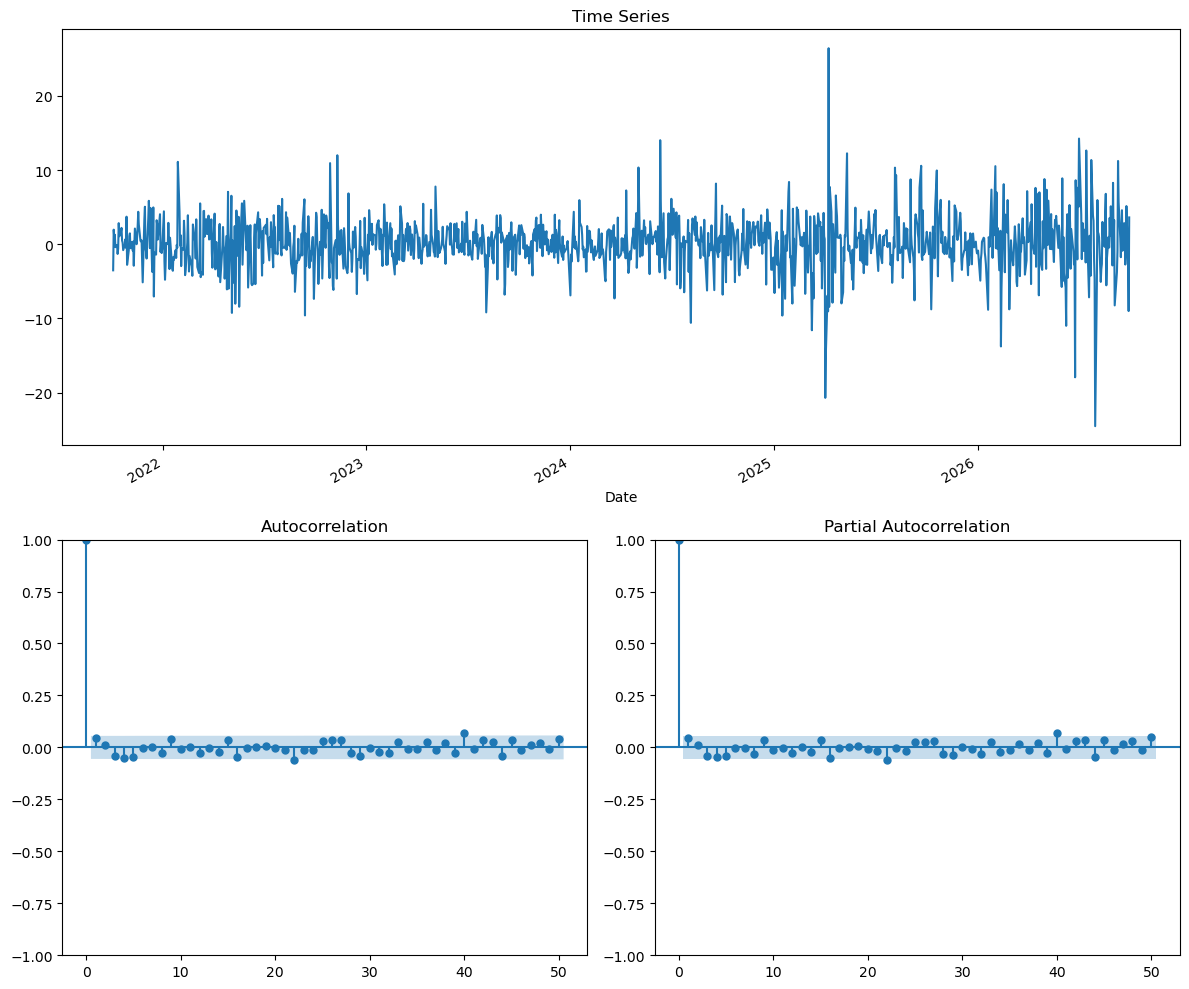

In [51]:
# plot the data with 50 lags
plotds(first_order_diff, nlag = 50)

# Perform Dicky Fuller test
adf_result = adfuller(first_order_diff)

# Display the outcomes
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])

ADF test: p = 0.000 < 0.05, so the differenced series is stationary. One difference was enough, so d = 1

ACF and PACF have no clear spikes after lag 0, so this suggests p = 0 and q = 0, which I'll check with AIC.

This followed tutorial 5a

My dataset has 1254 rows for 5 years, so 1254 / 5 ≈ 251 rows per year. This is close to 252, the usual number of trading days in one year, so I chose 252 as the period

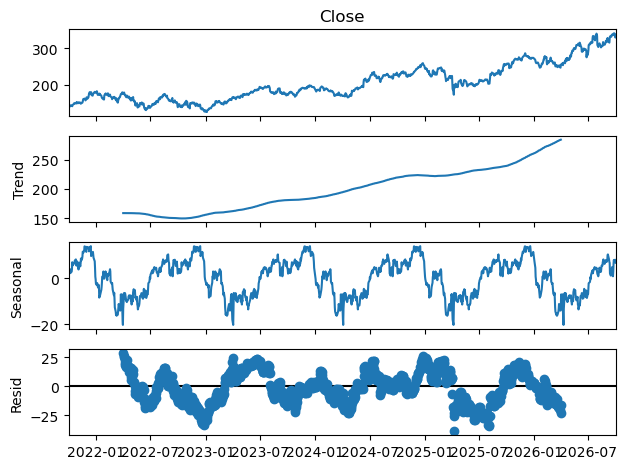

seasonal_var= 62.626331, resid_var= 175.418045


In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose

# decompose the data using seasonal_decompose() function
decomposition = seasonal_decompose(AAPL_df['Close'], period = 252, model = 'additive')

# Plot the function using plot()
decomposition.plot()
plt.show()
print("seasonal_var= %f, resid_var= %f" % (decomposition.seasonal.var(), decomposition.resid.var()))

The trend is going up from about 150 to above 250, which is what I conclude from the graph. 

The seasonality is not strong, because the residual variance (about 175) is bigger than the seasonal variance (about 63).

I'll use ARIMA and not SARIMA, because my data has a trend but weak seasonality.
